In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import f_oneway, kruskal
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from itertools import product 
from time import time
import seaborn as sns
import matplotlib.pyplot as plt

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from utils.analysis import get_query_string_hyps_filter, load_dbscan_labels

# Feature Importance Analysis
&#8594; Determine whether the mean values of the scaled parameters differ significantly across clusters 

In [2]:
# Load data
df_in = pd.read_csv(f"{config.output_dir}wide_table_knn.csv") 
df = df_in.drop(["LATITUDE", "LONGITUDE", "LEV_M", "imputed", "water"], axis=1)  # Remove unneeded information

In [3]:
# Scale data
scaler = MinMaxScaler().fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)

# Combine dataframes
df_total = df_in.copy()
for p in ["P_TEMPERATURE", "P_SALINITY", "P_OXYGEN", "P_NITRATE", "P_SILICATE", "P_PHOSPHATE"]:
    df_total[p + "_scaled"] = df_scaled[p]

In [4]:
def rf(df, x_columns, y_column="label", forest_hyps={}):
    """ Train a random forest to mimic a clustering model. """
    X = df[x_columns]
    y = df[y_column]
    rf_results = []

    # Train a random forest
    rf_clf = RandomForestClassifier(random_state=42, 
                                    oob_score=True,
                                    verbose=True,
                                    **forest_hyps, 
                                    #max_features=0.5,        # Control feature selection per split
                                    #min_samples_leaf=3,      # Avoid overfitting by limiting leaf size
                                    # max_depth=max_depth,          # Allow deep trees for complex separations (but not too deep as there are some cases with high numbers of clusters)
                                    n_estimators=1000,        # More trees to improve robustness (some clusters are challenging to separate, small clusters)
                                    class_weight="balanced")  # Ensure that small clusters contribute equally to decision
    rf_clf.fit(X, y)
    
    # Get feature importance
    rf_importance = rf_clf.feature_importances_
    
    # Store results
    for param, importance in zip(X.columns, rf_importance):
        rf_results.append(pd.DataFrame({"parameter": [param], "importance": [importance], "oob": [rf_clf.oob_score_]}))

    return pd.concat(rf_results).sort_values("importance", ascending=False).reset_index(drop=True)

In [5]:
# Training and UMAP columns
x_cols = ['P_TEMPERATURE_scaled', 'P_SALINITY_scaled', 'P_OXYGEN_scaled', 'P_NITRATE_scaled', 'P_SILICATE_scaled', 'P_PHOSPHATE_scaled']
umap_cols = [f"e{i}" for i in range(hyp_config.umap_hyps["n_components"])]

## Compute feature importances

In [9]:
def smart_forest_hyps(n_clusters, class_limit=400, multiplier=1.5, depth_cap=20):
    """ Define max_depth for the RandomForestClassifier in a ressource efficient way. """
    if n_clusters <= class_limit:
        max_depth = None
        min_samples_leaf = 1
    else:
        max_depth = min(depth_cap, int(np.log2(n_clusters) * multiplier))
        min_samples_leaf = 5
        
    return {"max_depth": max_depth, "min_samples_leaf": min_samples_leaf}

In [21]:
# Feature importance for all hyperparameter combinations
for cluster_name, (ClusterAlgo, param_grid) in config.algorithms_and_hyps.items():
    if cluster_name == "dbscan": 
        print(cluster_name)
        
        # Generate all hyperparameter combinations
        hyp_param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
    
        # Load data
        if cluster_name != "dbscan": 
            print(f"Load data for {cluster_name}...")
            data_file = f"{config.output_dir_clustering}/labels_{cluster_name}.csv"
            df_feature_importance = pd.read_csv(data_file)

        # Iterate over iterations
        for i in range(config.n_iterations): 
            print(f"  Iteration {i}")

            # For DBSCAN, we need to load each iteration separately
            if cluster_name == "dbscan": 
                print("    Loading DBSCAN data...")
                df_feature_importance = load_dbscan_labels(iteration=i) 
                # Ensure proper data types
                df_feature_importance["eps"] = df_feature_importance["eps"].astype(float)
                df_feature_importance["min_samples"] = df_feature_importance["min_samples"].astype(int)
        
            # Iterate over hyperparameter combinations
            for hyp_params in hyp_param_combinations:
                    
                filename = f"{config.output_dir_feature_importance}feature_importance_iteration{i}_{cluster_name}_{'_'.join([f'{k}{v}' for k, v in hyp_params.items()])}.csv"
                
                # Only compute if it has not been done before 
                if not Path(filename).exists():
                    print(f"    Now computing: {filename}")
                    res = []
                    
                    # Iterate over prepprocessings
                    for preprocessing in config.preprocessings.keys():    

                        # Get labels
                        start_time = time()
                        query_str = get_query_string_hyps_filter(hyp_params, preproc=preprocessing, iteration=i)    
                        temp = df_feature_importance.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]
    
                        # Add parameter information
                        temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
    
                        # Train RF (for DBSCAN, we limit the max_depth since there are some cluster sets with >6000 labels)
                        forest_hyps = smart_forest_hyps(n_clusters=len(temp["label"].unique()), class_limit=500, multiplier=1.5, depth_cap=20)
                        print(f"    {forest_hyps}\n    Number of clusters: {len(temp.label.unique())}")
                        forest = rf(temp, x_columns=x_cols, forest_hyps=forest_hyps)
   
                        end_time = time()
    
                        # Append results
                        forest_dict = forest.to_dict()
                        forest_flat = [
                            {"parameter": forest_dict["parameter"][i],
                             "importance": forest_dict["importance"][i],
                             "oob": forest_dict["oob"][i]}
                            for i in forest_dict["parameter"]
                        ]
                        for row in forest_flat:
                            res.append({**{
                                "iteration": i,
                                "preprocessing": preprocessing,
                                "clustering": cluster_name,
                                "importance_time": end_time - start_time,
                            }, **hyp_params, **row})
    
                    # Store results (in one file, we will have both preprocessings)
                    res = pd.DataFrame(res)
                    res.to_csv(filename, index=False)
                else:
                    print(f"Skipping. File already exists: {filename}")

dbscan
  Iteration 1
    Loading DBSCAN data...
    Now computing: output/feature_importance/feature_importance_iteration1_dbscan_eps0.11627118644067796_min_samples5.csv
    Max depth: None
    Number of clusters: 9
    Max depth: None
    Number of clusters: 283
    Now computing: output/feature_importance/feature_importance_iteration1_dbscan_eps0.1194915254237288_min_samples11.csv
    Max depth: None
    Number of clusters: 4
    Max depth: None
    Number of clusters: 350
  Iteration 2
    Loading DBSCAN data...
    Now computing: output/feature_importance/feature_importance_iteration2_dbscan_eps0.11627119_min_samples5.csv
    Max depth: None
    Number of clusters: 9
    Max depth: None
    Number of clusters: 278
    Now computing: output/feature_importance/feature_importance_iteration2_dbscan_eps0.11949153_min_samples11.csv
    Max depth: None
    Number of clusters: 4
    Max depth: None
    Number of clusters: 350
  Iteration 3
    Loading DBSCAN data...
    Now computing: outp

In [ ]:
# Store feature importance results (and remove temporary files)
for cluster_name in config.algorithms_and_hyps.keys():
    print(cluster_name)

    res = []
    files_to_remove = []
    
    for file in Path(config.output_dir_feature_importance).glob(f"feature_importance_iteration*_{cluster_name}_*.csv"):
        res.append(pd.read_csv(file))
        files_to_remove.append(file)
    
    # Store results
    res = pd.concat(res)
    res.to_csv(f"{config.output_dir_feature_importance}feature_importance_{cluster_name}.csv", index=False)
    
    # Remove temporary files
    for file in files_to_remove:
        if file.exists():  
            file.unlink()

## Analyse feature importances

In [6]:
fi_kmeans = pd.read_csv(f"{config.output_dir_feature_importance}feature_importance_kmeans.csv")
fi_ward = pd.read_csv(f"{config.output_dir_feature_importance}feature_importance_ward.csv")
fi_dbscan = pd.read_csv(f"{config.output_dir_feature_importance}feature_importance_dbscan.csv")

fi = pd.concat([fi_kmeans, fi_ward, fi_dbscan], ignore_index=True)

In [7]:
# Rename parameters
rename_parameter_dict = {
    "P_TEMPERATURE_scaled": "Temperature",
    "P_SALINITY_scaled": "Salinity",
    "P_OXYGEN_scaled": "Oxygen",
    "P_PHOSPHATE_scaled": "Phosphate",
    "P_NITRATE_scaled": "Nitrate",
    "P_SILICATE_scaled": "Silicate"
}

rename_preprocessings_dict = {
    "minmax": "MinMax",
    "minmax_umap": "MinMax-UMAP"
}

# Apply renaming to the 'parameter' column
fi["parameter"] = fi["parameter"].replace(rename_parameter_dict)
fi["preprocessing"] = fi["preprocessing"].replace(rename_preprocessings_dict)

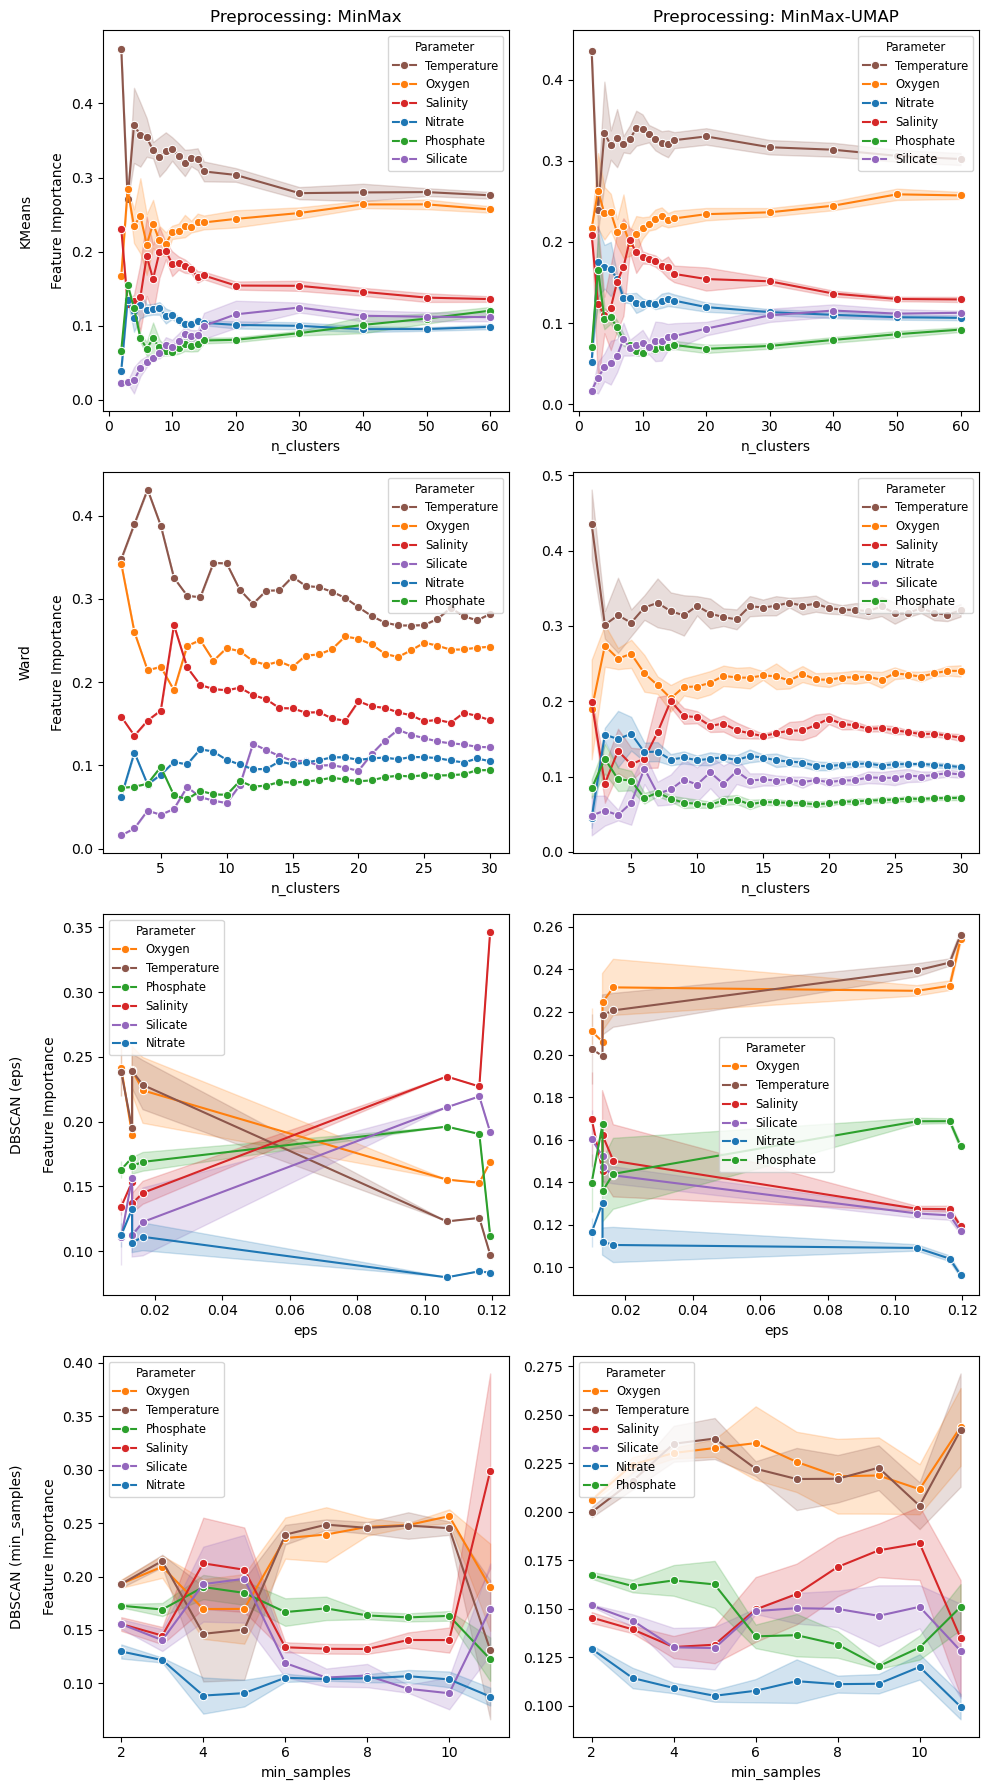

In [8]:
# 1. Get all unique parameters and assign consistent colors
unique_params = sorted(fi['parameter'].unique())
palette = sns.color_palette("tab10", n_colors=len(unique_params))
param_color_dict = dict(zip(unique_params, palette))

# 2. Define the unique preprocessing methods (columns)
preprocs = sorted(fi['preprocessing'].unique())
n_cols = len(preprocs)
n_rows = 4  # KMeans, Ward, DBSCAN (eps), DBSCAN (min_samples)

# 3. Set up subplot grid WITHOUT shared axes
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    sharex=False,
    sharey=False
)

# 4. Define mapping: (row title, filter, x-axis variable)
row_specs = [
    ("KMeans", lambda df: df['clustering'] == 'kmeans', 'n_clusters'),
    ("Ward", lambda df: df['clustering'] == 'ward', 'n_clusters'),
    ("DBSCAN (eps)", lambda df: (df['clustering'] == 'dbscan') & (df.groupby(['iteration', 'preprocessing'])['eps'].transform('nunique') > 1), 'eps'),
    ("DBSCAN (min_samples)", lambda df: (df['clustering'] == 'dbscan') & (df.groupby(['iteration', 'preprocessing'])['min_samples'].transform('nunique') > 1), 'min_samples'),
]

# 5. Plotting loop
for row_idx, (row_title, row_filter, x_var) in enumerate(row_specs):
    for col_idx, preproc in enumerate(preprocs):
        ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]

        # Filter data for subplot
        mask = (fi['preprocessing'] == preproc)
        subset = fi[mask & row_filter(fi)]

        if not subset.empty:
            sns.lineplot(
                data=subset,
                x=x_var,
                y='importance',
                hue='parameter',
                palette=param_color_dict,  
                ax=ax,
                marker='o',
                errorbar='sd',
                legend=True
            )
            ax.legend(title="Parameter", fontsize='small', title_fontsize='small')
        else:
            ax.legend().remove()

        # Titles and labels
        if row_idx == 0:
            ax.set_title(f"Preprocessing: {preproc}")
        if col_idx == 0:
            ax.set_ylabel(f"{row_title}\n\nFeature Importance")
        else:
            ax.set_ylabel("")

        ax.set_xlabel(x_var)

plt.tight_layout()
plt.show()


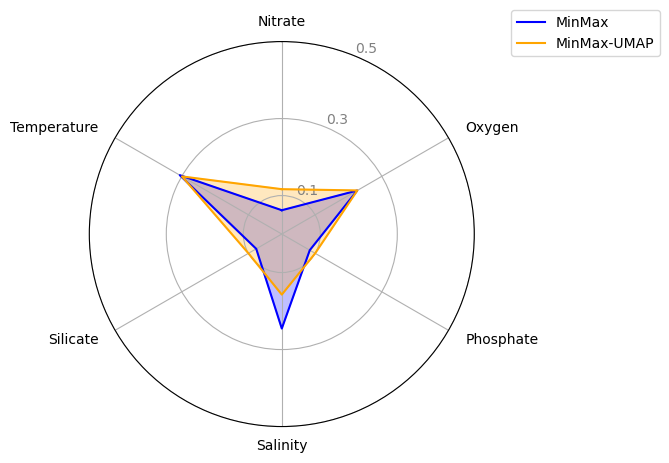

In [9]:
# Spider plot for final hyperparameter combinations

# Concat all feature importances from final hyperparameter combinations
temp = pd.concat([fi.query(get_query_string_hyps_filter(hyp_config.kmeans_original_hyps, preproc="MinMax", algorithm="kmeans", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.kmeans_umap_hyps, preproc="MinMax-UMAP", algorithm="kmeans", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.ward_original_hyps, preproc="MinMax", algorithm="ward", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.ward_umap_hyps, preproc="MinMax-UMAP", algorithm="ward", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.dbscan_original_hyps, preproc="MinMax", algorithm="dbscan", float_tol=1e-8)),
                  fi.query(get_query_string_hyps_filter(hyp_config.dbscan_umap_hyps, preproc="MinMax-UMAP", algorithm="dbscan", float_tol=1e-8))
                 ])

# Compute mean importance by data type
radar_data = temp[['parameter', 'importance', 'preprocessing']].groupby(["parameter", "preprocessing"]).mean().reset_index()
radar_original = radar_data[radar_data["preprocessing"] == "MinMax"].set_index("parameter")["importance"]
radar_embedded = radar_data[radar_data["preprocessing"] == "MinMax-UMAP"].set_index("parameter")["importance"]

# Radar chart preparation
categories = radar_original.index.tolist()
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Plot
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.plot(angles, radar_original.tolist() + radar_original[:1].tolist(), label="MinMax", color="blue")
ax.fill(angles, radar_original.tolist() + radar_original[:1].tolist(), alpha=0.25, color="blue")
ax.plot(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), label="MinMax-UMAP", color="orange")
ax.fill(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), alpha=0.25, color="orange")

# Formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, ha='center')  

# Use external padding for labels
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, np.pi):  # Top and bottom labels
        label.set_verticalalignment('center')
    elif 0 < angle < np.pi:  # Right-side labels
        label.set_horizontalalignment('left')
    else:  # Left-side labels
        label.set_horizontalalignment('right')
        
ax.set_yticks([0.1, 0.3, 0.5])
ax.set_yticklabels(["0.1", "0.3", "0.5"], color="gray")#, size=10)
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.1))

#plt.tight_layout()
plt.savefig(f"{config.output_dir_plots_high_res}feature_importance_data_comparison.png", bbox_inches="tight", dpi=1000)
plt.show()


### KMeans

In [10]:
# Mean feature importances for KMeans 
query_str = get_query_string_hyps_filter(hyp_config.kmeans_original_hyps, preproc="MinMax", algorithm="kmeans", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.039729,0.9965
Oxygen,0.167138,0.9965
Phosphate,0.066700,0.9965
Salinity,0.230924,0.9965
Silicate,0.022257,0.9965
Temperature,0.473253,0.9965


In [11]:
# Mean feature importances for KMeans on the embedding
query_str = get_query_string_hyps_filter(hyp_config.kmeans_umap_hyps, preproc="MinMax-UMAP", algorithm="kmeans", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.123399,0.983418
Oxygen,0.217240,0.983418
Phosphate,0.063568,0.983418
Salinity,0.180925,0.983418
Silicate,0.075983,0.983418
Temperature,0.338884,0.983418


### Ward

In [12]:
# Mean feature importances for Ward 
query_str = get_query_string_hyps_filter(hyp_config.ward_original_hyps, preproc="MinMax", algorithm="ward", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.062680,0.996308
Oxygen,0.342185,0.996308
Phosphate,0.073033,0.996308
Salinity,0.158481,0.996308
Silicate,0.015986,0.996308
Temperature,0.347634,0.996308


In [13]:
# Mean feature importances for Ward on the embedding
query_str = get_query_string_hyps_filter(hyp_config.ward_umap_hyps, preproc="MinMax-UMAP", algorithm="ward", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.117238,0.974471
Oxygen,0.232635,0.974471
Phosphate,0.068094,0.974471
Salinity,0.163476,0.974471
Silicate,0.099030,0.974471
Temperature,0.319528,0.974471


### DBSCAN

In [14]:
# Mean feature importances for DBSCAN 
query_str = get_query_string_hyps_filter(hyp_config.dbscan_original_hyps, preproc="MinMax", algorithm="dbscan", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.083291,0.998654
Oxygen,0.168770,0.998654
Phosphate,0.111974,0.998654
Salinity,0.346814,0.998654
Silicate,0.191887,0.998654
Temperature,0.097263,0.998654


In [15]:
# Mean feature importances for DBSCAN on the embedding
query_str = get_query_string_hyps_filter(hyp_config.dbscan_umap_hyps, preproc="MinMax-UMAP", algorithm="dbscan", float_tol=1e-8)
fi.query(query_str)[["importance", "oob", "parameter"]].groupby(["parameter"]).mean()

,importance,oob
parameter,,
Nitrate,0.109083,0.914846
Oxygen,0.229942,0.914846
Phosphate,0.168627,0.914846
Salinity,0.127481,0.914846
Silicate,0.125279,0.914846
Temperature,0.239588,0.914846


### Final clustering (NEMI)

In [16]:
# Load final cluster set
df_final = pd.read_csv(f"{config.output_dir}cluster_set.csv")

# Add scaled parameters
temp = df_total.merge(df_final[["label", "LATITUDE", "LONGITUDE", "LEV_M"]], on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")

In [23]:
# Compute the RandomForestClassifier
rf_final = rf(temp, x_columns=x_cols)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed: 13.2min finished


In [24]:
# Show results
rf_final

,parameter,importance,oob
0,P_TEMPERATURE_scaled,0.239499,0.921864
1,P_OXYGEN_scaled,0.226753,0.921864
2,P_PHOSPHATE_scaled,0.173780,0.921864
3,P_SALINITY_scaled,0.126502,0.921864
4,P_SILICATE_scaled,0.122203,0.921864
5,P_NITRATE_scaled,0.111263,0.921864


In [25]:
# Store results
rf_final.to_csv(f"{config.output_dir_feature_importance}feature_importance_nemi.csv", index=False)